In [1]:
# ============================================================
# CELL 1 — Install & Import Libraries (IMPROVED)
# ============================================================

!pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, os, warnings

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ============================================================
# CONSTANTS
# ============================================================
RANDOM_STATE    = 42
TEST_SIZE       = 0.20
CV_FOLDS        = 5
PSEUDO_CONF_R   = 0.80   # stricter Resistant harvest
PSEUDO_CONF_S   = 0.20   # stricter Susceptible harvest
MAX_SUS_RATIO   = 2.5    # keep pseudo-label class ratio sane
MIN_COMBO_SIZE  = 5      # min samples for target encoding combos

print("✅ Libraries imported.")
print(f"   pandas   : {pd.__version__}")
print(f"   xgboost  : {xgb.__version__}")


✅ Libraries imported.
   pandas   : 2.2.2
   xgboost  : 3.2.0


  RAW DATASET AUDIT
  Shape        : 171,000 rows × 21 columns
  Memory       : 140.3 MB

--- Missing value summary ---
                                  null_count  null_pct    dtype
Laboratory Typing Method Version      170991   99.9900   object
Source                                170938   99.9600   object
Laboratory Typing Platform            169694   99.2400   object
Measurement Sign                      168014   98.2500   object
Testing Standard Year                 167299   97.8400  float64
Testing Standard                      165760   96.9400   object
PubMed                                164163   96.0000   object
Laboratory Typing Method              162929   95.2800   object
Vendor                                134222   78.4900   object
Resistant Phenotype                    87829   51.3600   object
Measurement Value                      82441   48.2100   object
Measurement Unit                       82441   48.2100   object
Measurement                            82441   4

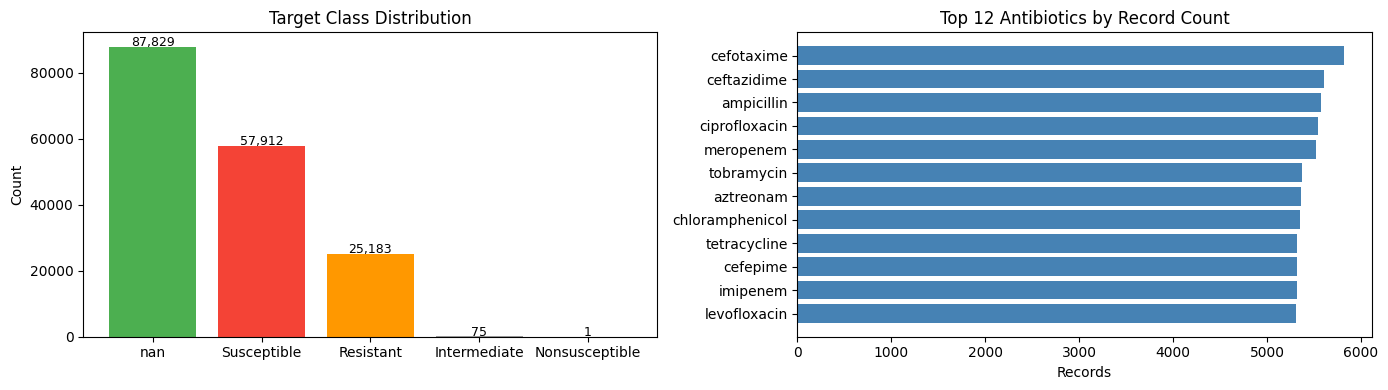

Saved: eda_overview.png


In [4]:
# ============================================================
# CELL 2 — Load Dataset & Initial Audit
# ============================================================

FILE_PATH = "/content/drive/Shareddrives/ML_Loopverse_2.0/BVBRC_genome_amr.csv"   # update if needed

df_raw = pd.read_csv(FILE_PATH, low_memory=False)

print("=" * 55)
print("  RAW DATASET AUDIT")
print("=" * 55)
print(f"  Shape        : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Memory       : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n--- Missing value summary ---")
null_df = pd.DataFrame({
    'null_count': df_raw.isnull().sum(),
    'null_pct'  : (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'dtype'     : df_raw.dtypes
}).sort_values('null_pct', ascending=False)
print(null_df.to_string())

print("\n--- Target distribution ---")
print(df_raw['Resistant Phenotype'].value_counts(dropna=False).to_string())

print(f"\n--- Unique antibiotics : {df_raw['Antibiotic'].nunique()} ---")
print(df_raw['Antibiotic'].value_counts().head(10).to_string())

# ── IMPROVEMENT: EDA plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
vc = df_raw['Resistant Phenotype'].value_counts(dropna=False)
axes[0].bar(vc.index.astype(str), vc.values, color=['#4CAF50','#F44336','#FF9800','#9E9E9E'])
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{bar.get_height():,}", ha='center', fontsize=9)

# Top antibiotics
top_ab = df_raw['Antibiotic'].value_counts().head(12)
axes[1].barh(top_ab.index[::-1], top_ab.values[::-1], color='steelblue')
axes[1].set_title('Top 12 Antibiotics by Record Count')
axes[1].set_xlabel('Records')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_overview.png")


In [11]:
# ============================================================
# CELL 3 — Full Cleaning Pipeline
# ============================================================
# KEY DECISIONS:
#   1. STRAIN DROPPED — 100k+ unique values → overfitting bait.
#   2. mic_value null fill → 0; has_mic flag marks missing rows.
#   3. MIC Rule-Based Rescue labels high-confidence unlabeled rows.
#   4. Deduplication keeps lab-confirmed labels over computational.
#   5. Sample weights derived from computational F1 scores.
#   NOTE: df_unlabeled is kept only for the submission CSV at the end.
# ============================================================

import pandas as pd
import numpy as np
import re

df = df_raw.copy()
print(f"Starting shape: {df.shape[0]:,} rows\n")

# ----------------------------------------------------------
# STEP 1 — Parse MIC
# ----------------------------------------------------------
MIC_SIGN_MAP = {'<=': -1.0, '<': -0.5, '=': 0.0, '==': 0.0,
                'exact': 0.0, '>=': 1.0, '>': 0.5, 'unknown': 0.0}

def parse_mic_sign(val):
    if pd.isna(val): return 'unknown'
    val = str(val).strip()
    for op in ['<=', '>=', '==', '<', '>', '=']:
        if val.startswith(op): return op
    return 'exact'

def parse_mic_numeric(val):
    if pd.isna(val): return np.nan
    m = re.search(r'(\d+\.?\d*)', str(val))
    return float(m.group(1)) if m else np.nan

df['mic_sign']  = df['Measurement'].apply(parse_mic_sign)
df['mic_value'] = df['Measurement'].apply(parse_mic_numeric)

mask_no_mic = df['mic_value'].isna()
df.loc[mask_no_mic, 'mic_value'] = (
    df.loc[mask_no_mic, 'Measurement Value']
      .astype(str).apply(parse_mic_numeric)
)
df['has_mic'] = df['mic_value'].notna().astype(int)
print(f"STEP 1 — MIC parsed | with MIC: {df['mic_value'].notna().sum():,}")

# ----------------------------------------------------------
# STEP 2 — Extract Genus & Species (strain intentionally skipped)
# ----------------------------------------------------------
def extract_genome_parts(name):
    if pd.isna(name):
        return pd.Series({'genus': 'unknown', 'species': 'unknown'})
    parts = str(name).strip().split(None, 2)
    genus   = parts[0].strip("\'\"").capitalize() if len(parts) > 0 else 'unknown'
    species = parts[1].lower()                    if len(parts) > 1 else 'unknown'
    return pd.Series({'genus': genus, 'species': species})

genome_parts = df['Genome Name'].apply(extract_genome_parts)
df = pd.concat([df, genome_parts], axis=1)
print(f"STEP 2 — Parsed | genera: {df['genus'].nunique()} | species: {df['species'].nunique()}")

# ----------------------------------------------------------
# STEP 3 — Split labeled / unlabeled
# ----------------------------------------------------------
df_unlabeled = df[df['Resistant Phenotype'].isna()].copy()
df           = df[df['Resistant Phenotype'].notna()].copy()
print(f"\nSTEP 3 — Labeled: {len(df):,} | Unlabeled (for submission): {len(df_unlabeled):,}")

# ----------------------------------------------------------
# STEP 4 — Normalize Target (merge Intermediate → Resistant)
# ----------------------------------------------------------
merge_map = {
    'Susceptible'   : 'Susceptible',
    'Resistant'     : 'Resistant',
    'Intermediate'  : 'Resistant',
    'Nonsusceptible': 'Resistant',
}
df['Resistant Phenotype'] = df['Resistant Phenotype'].map(merge_map)
df['target'] = (df['Resistant Phenotype'] == 'Resistant').astype(int)
df['Antibiotic']           = df['Antibiotic'].str.strip().str.lower()
df_unlabeled['Antibiotic'] = df_unlabeled['Antibiotic'].str.strip().str.lower()

vc = df['target'].value_counts()
print(f"STEP 4 — Susceptible (0): {vc[0]:,} | Resistant (1): {vc[1]:,}")

# ----------------------------------------------------------
# STEP 5 — MIC Rule-Based Rescue from unlabeled rows
# ----------------------------------------------------------
print("\nSTEP 5 — MIC Rule-Based Rescue...")
s_bounds = df[df['target'] == 0].groupby('Antibiotic')['mic_value'].quantile(0.90)
r_bounds = df[df['target'] == 1].groupby('Antibiotic')['mic_value'].quantile(0.10)

rescued_rows = []
for idx, row in df_unlabeled.iterrows():
    if pd.isna(row['mic_value']): continue
    ab  = row['Antibiotic']
    mic = row['mic_value']
    if ab not in s_bounds.index or ab not in r_bounds.index: continue
    s_max = s_bounds[ab];  r_min = r_bounds[ab]
    if mic <= s_max and mic < r_min:
        r = row.copy(); r['target'] = 0; rescued_rows.append(r)
    elif mic >= r_min and mic > s_max:
        r = row.copy(); r['target'] = 1; rescued_rows.append(r)

if rescued_rows:
    df_rescued = pd.DataFrame(rescued_rows)
    df_rescued['Resistant Phenotype'] = df_rescued['target'].map({0:'Susceptible',1:'Resistant'})
    df = pd.concat([df, df_rescued], axis=0).reset_index(drop=True)
    df_unlabeled = df_unlabeled[~df_unlabeled.index.isin(df_rescued.index)].copy()
    print(f"         Rescued: {len(df_rescued):,} rows added to training")
else:
    print("         No rows rescued.")
print(f"         Training pool: {len(df):,} | Remaining unlabeled: {len(df_unlabeled):,}")

# ----------------------------------------------------------
# STEP 6 — Deduplication (lab-confirmed wins over computational)
# ----------------------------------------------------------
df['is_lab_confirmed'] = (df['Evidence'] == 'Laboratory Method').astype(int)
before = len(df)
df = (df.sort_values(['Genome ID','Antibiotic','is_lab_confirmed'],
                     ascending=[True,True,False])
        .drop_duplicates(subset=['Genome ID','Antibiotic'], keep='first')
        .reset_index(drop=True))
print(f"\nSTEP 6 — Duplicates removed: {before - len(df):,}")

# ----------------------------------------------------------
# STEP 7 — Drug Class Mapping
# ----------------------------------------------------------
DRUG_CLASS_MAP = {
    'ampicillin':'beta_lactam','amoxicillin':'beta_lactam',
    'piperacillin':'beta_lactam','piperacillin/tazobactam':'beta_lactam',
    'oxacillin':'beta_lactam','cefazolin':'beta_lactam',
    'cefoxitin':'beta_lactam','cefotaxime':'beta_lactam',
    'ceftazidime':'beta_lactam','ceftriaxone':'beta_lactam',
    'cefepime':'beta_lactam','cefuroxime':'beta_lactam','cephalothin':'beta_lactam',
    'imipenem':'carbapenem','meropenem':'carbapenem',
    'ertapenem':'carbapenem','doripenem':'carbapenem',
    'aztreonam':'monobactam',
    'ciprofloxacin':'fluoroquinolone','levofloxacin':'fluoroquinolone',
    'norfloxacin':'fluoroquinolone','nalidixic acid':'fluoroquinolone','ofloxacin':'fluoroquinolone',
    'gentamicin':'aminoglycoside','tobramycin':'aminoglycoside',
    'amikacin':'aminoglycoside','streptomycin':'aminoglycoside',
    'neomycin':'aminoglycoside','kanamycin':'aminoglycoside',
    'tetracycline':'tetracycline','doxycycline':'tetracycline',
    'minocycline':'tetracycline','tigecycline':'tetracycline',
    'sulfamethoxazole':'sulfonamide','trimethoprim':'sulfonamide',
    'trimethoprim/sulfamethoxazole':'sulfonamide',
    'chloramphenicol':'phenicol',
    'azithromycin':'macrolide','erythromycin':'macrolide',
    'colistin':'polymyxin','polymyxin b':'polymyxin',
    'vancomycin':'glycopeptide','teicoplanin':'glycopeptide',
    'clindamycin':'lincosamide','nitrofurantoin':'nitrofuran',
    'rifampicin':'rifamycin','rifampin':'rifamycin',
}
df['drug_class']           = df['Antibiotic'].map(DRUG_CLASS_MAP).fillna('other')
df_unlabeled['drug_class'] = df_unlabeled['Antibiotic'].map(DRUG_CLASS_MAP).fillna('other')
print(f"\nSTEP 7 — Drug classes assigned.")

# ----------------------------------------------------------
# STEP 8 — Sample Weights (by label quality)
# ----------------------------------------------------------
def extract_f1_score(text):
    if pd.isna(text): return np.nan
    m = re.search(r'F1 score:\s*([\d.]+)', str(text))
    return float(m.group(1)) if m else np.nan

df['computational_f1'] = df['Computational Method Performance'].apply(extract_f1_score)
df.loc[df['is_lab_confirmed'] == 1, 'computational_f1'] = 1.0
median_f1 = df['computational_f1'].median()
df['computational_f1'] = df['computational_f1'].fillna(median_f1)
df['sample_weight']    = df['computational_f1'].clip(0.5, 1.0)
print(f"\nSTEP 8 — Sample weights: {df['sample_weight'].min():.2f} – {df['sample_weight'].max():.2f}")

# ----------------------------------------------------------
# STEP 9 — Drop raw columns
# ----------------------------------------------------------
DROP_FINAL = [
    'Genome Name','Resistant Phenotype',
    'Measurement','Measurement Sign','Measurement Value','Measurement Unit',
    'Laboratory Typing Method','Laboratory Typing Method Version',
    'Laboratory Typing Platform','Vendor','Testing Standard','Testing Standard Year',
    'Computational Method','Computational Method Version',
    'Computational Method Performance','Evidence','Source','PubMed',
]
DROP_FINAL = [c for c in DROP_FINAL if c in df.columns]
df.drop(columns=DROP_FINAL, inplace=True)
print(f"\nSTEP 9 — Dropped {len(DROP_FINAL)} raw columns")

# ----------------------------------------------------------
# STEP 10 — Fill nulls
# ----------------------------------------------------------
df['mic_value'] = df['mic_value'].fillna(0)
df['mic_sign']  = df['mic_sign'].fillna('unknown')

print(f"\n{'='*55}")
print(f"  CLEANING COMPLETE")
print(f"  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
vc = df['target'].value_counts()
print(f"  Target: 0={vc[0]:,} | 1={vc[1]:,}")

df_clean = df.copy()
print("\n✅ df_clean ready.")


Starting shape: 171,000 rows

STEP 1 — MIC parsed | with MIC: 88,560
STEP 2 — Parsed | genera: 1 | species: 1

STEP 3 — Labeled: 83,171 | Unlabeled (for submission): 87,829
STEP 4 — Susceptible (0): 57,912 | Resistant (1): 25,259

STEP 5 — MIC Rule-Based Rescue...
         Rescued: 44,660 rows added to training
         Training pool: 127,831 | Remaining unlabeled: 43,169

STEP 6 — Duplicates removed: 1,964

STEP 7 — Drug classes assigned.

STEP 8 — Sample weights: 0.76 – 1.00

STEP 9 — Dropped 18 raw columns

  CLEANING COMPLETE
  Shape : 125,867 rows × 13 columns
  Target: 0=84,640 | 1=41,227

✅ df_clean ready.


In [12]:
# ============================================================
# CELL 4 — Feature Engineering & Train/Test Split
# ============================================================
# - OrdinalEncoder for categoricals (Antibiotic, drug_class, genus, species)
# - mic_log: log1p transform (MIC is log-normally distributed)
# - 5-fold CV target encodings (leak-safe)
# - df_unlabeled encoded separately for submission CSV only
# ============================================================

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, KFold
import numpy as np
import pandas as pd

df = df_clean.copy()

# mic_sign → numeric, mic_log transform
df['mic_sign_encoded'] = df['mic_sign'].map(MIC_SIGN_MAP).fillna(0.0)
df['mic_log'] = np.log1p(df['mic_value'].clip(lower=0))

# Ordinal encode categoricals
CAT_COLS = ['Antibiotic', 'drug_class', 'genus', 'species']
df[CAT_COLS] = df[CAT_COLS].astype(str)

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[CAT_COLS] = enc.fit_transform(df[CAT_COLS])

print("OrdinalEncoder applied:")
for col, cats in zip(CAT_COLS, enc.categories_):
    print(f"  {col:15s}: {len(cats)} categories")

BASE_FEATURES = [
    'Taxon ID', 'Antibiotic', 'drug_class', 'genus', 'species',
    'is_lab_confirmed', 'computational_f1',
    'mic_sign_encoded', 'mic_value', 'mic_log', 'has_mic',
]
TARGET = 'target'

# Stratified split
X = df[BASE_FEATURES]; y = df[TARGET]; w = df['sample_weight']
X_train_raw, X_test_raw, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"\nSplit — Train: {len(X_train_raw):,} | Test: {len(X_test_raw):,}")

# 5-fold CV target encoding (leak-safe)
print("\nBuilding target encodings with 5-fold CV...")
global_mean = y_train.mean()
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_df = X_train_raw.copy()
train_df['target'] = y_train.values

for col in ['ab_resistance_rate', 'taxon_ab_resistance_rate', 'genus_ab_resistance_rate']:
    train_df[col] = global_mean

for fold_idx, (trn_idx, val_idx) in enumerate(kf.split(train_df)):
    trn_fold = train_df.iloc[trn_idx]

    ab_rate = trn_fold.groupby('Antibiotic')['target'].mean()
    train_df.loc[train_df.index[val_idx], 'ab_resistance_rate'] = (
        train_df.iloc[val_idx]['Antibiotic'].map(ab_rate).fillna(global_mean).values
    )

    taxon_counts = trn_fold.groupby(['Taxon ID','Antibiotic'])['target'].count()
    taxon_rate   = trn_fold.groupby(['Taxon ID','Antibiotic'])['target'].mean()
    taxon_rate   = taxon_rate[taxon_counts >= MIN_COMBO_SIZE].reset_index()
    taxon_rate.columns = ['Taxon ID','Antibiotic','taxon_ab_resistance_rate']

    val_subset = train_df.iloc[val_idx].drop(columns=['taxon_ab_resistance_rate'])
    val_merged = val_subset.merge(taxon_rate, on=['Taxon ID','Antibiotic'], how='left')
    val_merged['taxon_ab_resistance_rate'] = val_merged['taxon_ab_resistance_rate'].fillna(
        val_merged['Antibiotic'].map(ab_rate).fillna(global_mean)
    )
    train_df.loc[train_df.index[val_idx], 'taxon_ab_resistance_rate'] = val_merged['taxon_ab_resistance_rate'].values

    genus_counts = trn_fold.groupby(['genus','Antibiotic'])['target'].count()
    genus_rate   = trn_fold.groupby(['genus','Antibiotic'])['target'].mean()
    genus_rate   = genus_rate[genus_counts >= MIN_COMBO_SIZE].reset_index()
    genus_rate.columns = ['genus','Antibiotic','genus_ab_resistance_rate']

    val_subset2 = train_df.iloc[val_idx].drop(columns=['genus_ab_resistance_rate'])
    val_merged2 = val_subset2.merge(genus_rate, on=['genus','Antibiotic'], how='left')
    val_merged2['genus_ab_resistance_rate'] = val_merged2['genus_ab_resistance_rate'].fillna(
        val_merged2['Antibiotic'].map(ab_rate).fillna(global_mean)
    )
    train_df.loc[train_df.index[val_idx], 'genus_ab_resistance_rate'] = val_merged2['genus_ab_resistance_rate'].values

print("  ✅ 5-fold target encoding complete")

# Full-train rates for test set encoding
ab_rate_full       = train_df.groupby('Antibiotic')['target'].mean()
taxon_ab_rate_full = (train_df.groupby(['Taxon ID','Antibiotic'])['target']
                      .agg(['sum','count'])
                      .query('count >= @MIN_COMBO_SIZE')
                      .assign(rate=lambda x: x['sum']/x['count'])['rate']
                      .rename('taxon_ab_resistance_rate').reset_index())
genus_ab_rate_full = (train_df.groupby(['genus','Antibiotic'])['target']
                      .agg(['sum','count'])
                      .query('count >= @MIN_COMBO_SIZE')
                      .assign(rate=lambda x: x['sum']/x['count'])['rate']
                      .rename('genus_ab_resistance_rate').reset_index())

def apply_target_encoding(df_in, ab_rate, taxon_rate, genus_rate, gmean):
    out = df_in.copy()
    out['ab_resistance_rate'] = out['Antibiotic'].map(ab_rate).fillna(gmean)
    out = out.merge(taxon_rate, on=['Taxon ID','Antibiotic'], how='left')
    out['taxon_ab_resistance_rate'] = out['taxon_ab_resistance_rate'].fillna(out['ab_resistance_rate'])
    out = out.merge(genus_rate, on=['genus','Antibiotic'], how='left')
    out['genus_ab_resistance_rate'] = out['genus_ab_resistance_rate'].fillna(out['ab_resistance_rate'])
    return out

X_train = train_df.drop(columns=['target'])
X_train['ab_resistance_rate'] = X_train['Antibiotic'].map(ab_rate_full).fillna(global_mean)
X_test  = apply_target_encoding(X_test_raw, ab_rate_full, taxon_ab_rate_full, genus_ab_rate_full, global_mean)

FINAL_FEATURES = BASE_FEATURES + [
    'ab_resistance_rate', 'taxon_ab_resistance_rate', 'genus_ab_resistance_rate',
]

X_train = X_train[FINAL_FEATURES].fillna(global_mean)
X_test  = X_test[FINAL_FEATURES].fillna(global_mean)

assert X_train.isnull().sum().sum() == 0, "Nulls in X_train!"
assert X_test.isnull().sum().sum()  == 0, "Nulls in X_test!"

# Encode unlabeled data for submission CSV
df_unlabeled_clean = df_unlabeled.copy()
df_unlabeled_clean['mic_sign_encoded'] = df_unlabeled_clean['mic_sign'].map(MIC_SIGN_MAP).fillna(0.0) if 'mic_sign' in df_unlabeled_clean.columns else 0.0
df_unlabeled_clean['mic_value']        = df_unlabeled_clean['mic_value'].fillna(0)
df_unlabeled_clean['mic_log']          = np.log1p(df_unlabeled_clean['mic_value'].clip(lower=0))
df_unlabeled_clean['has_mic']          = df_unlabeled_clean['mic_value'].apply(lambda x: 1 if x > 0 else 0)
for col in CAT_COLS:
    df_unlabeled_clean[col] = df_unlabeled_clean[col].astype(str) if col in df_unlabeled_clean.columns else 'unknown'
df_unlabeled_clean[CAT_COLS] = enc.transform(df_unlabeled_clean[CAT_COLS])
for col, default in [('is_lab_confirmed', 0), ('computational_f1', global_mean),
                     ('mic_sign_encoded', 0.0), ('genus', -1), ('species', -1)]:
    if col not in df_unlabeled_clean.columns:
        df_unlabeled_clean[col] = default
df_unlabeled_enc = apply_target_encoding(
    df_unlabeled_clean[BASE_FEATURES], ab_rate_full, taxon_ab_rate_full, genus_ab_rate_full, global_mean
)
df_unlabeled_enc = df_unlabeled_enc[FINAL_FEATURES].fillna(global_mean)

print(f"\nFINAL_FEATURES ({len(FINAL_FEATURES)}): {FINAL_FEATURES}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Unlabeled (submission): {df_unlabeled_enc.shape}")
print("\n✅ Cell 4 complete.")


OrdinalEncoder applied:
  Antibiotic     : 71 categories
  drug_class     : 14 categories
  genus          : 1 categories
  species        : 1 categories

Split — Train: 100,693 | Test: 25,174

Building target encodings with 5-fold CV...
  ✅ 5-fold target encoding complete

FINAL_FEATURES (14): ['Taxon ID', 'Antibiotic', 'drug_class', 'genus', 'species', 'is_lab_confirmed', 'computational_f1', 'mic_sign_encoded', 'mic_value', 'mic_log', 'has_mic', 'ab_resistance_rate', 'taxon_ab_resistance_rate', 'genus_ab_resistance_rate']
Train: (100693, 14) | Test: (25174, 14)
Unlabeled (submission): (43169, 14)

✅ Cell 4 complete.


scale_pos_weight : 2.0530  (neg=57,555 / pos=28,034)
Val size: 15,104  |  Test size (untouched): 25,174

Training XGBoost...
  Best iteration : 184
  Best AUC (val) : 0.8861

Running 5-fold Stratified CV on training set...
  Fold 1 AUC: 0.8855
  Fold 2 AUC: 0.8856
  Fold 3 AUC: 0.8798
  Fold 4 AUC: 0.8852
  Fold 5 AUC: 0.8805
  CV AUC: 0.8833 ± 0.0026

  Optimal threshold (from val set): 0.5310

  TEST SET RESULTS
  AUC-ROC              : 0.8893
  F1 weighted          : 0.7979
  F1 Resistant   (1)   : 0.7087
  F1 Susceptible (0)   : 0.8413
  Threshold            : 0.5310
                 precision    recall  f1-score   support

Susceptible (0)       0.88      0.81      0.84     16928
  Resistant (1)       0.66      0.76      0.71      8246

       accuracy                           0.79     25174
      macro avg       0.77      0.79      0.78     25174
   weighted avg       0.81      0.79      0.80     25174



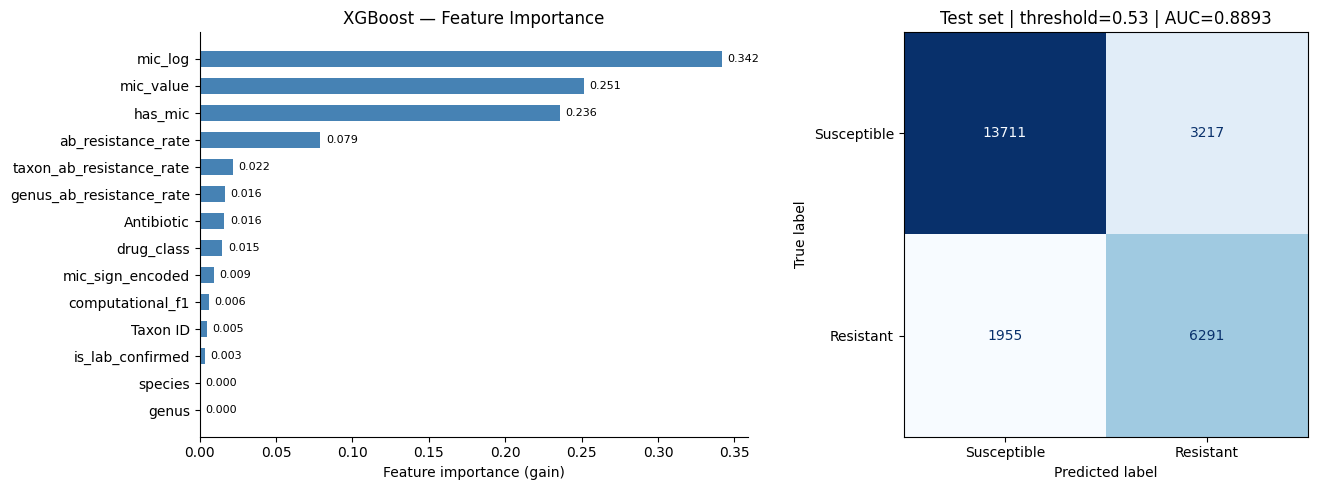

Saved: results_v4.png
Saved: amr_xgb_model_v4.joblib, amr_ordinal_encoder_v4.joblib
Saved: LoopVerse_Submission_XGB.csv (43,169 rows)

✅ Cell 5 complete.


In [13]:
# ============================================================
# CELL 5 — XGBoost Training
# ============================================================
# - Validation split carved from training (early stopping + threshold tuning)
# - scale_pos_weight handles class imbalance
# - 5-fold StratifiedKFold CV for stability check
# - Test set touched ONCE at the very end
# - Submission CSV generated from unlabeled rows
# ============================================================

import xgboost as xgb
import joblib
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt

# Carve validation set (NOT the test set)
X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X_train[FINAL_FEATURES], y_train, w_train,
    test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight : {scale_pos:.4f}  (neg={neg:,} / pos={pos:,})")
print(f"Val size: {len(X_val):,}  |  Test size (untouched): {len(X_test):,}\n")

model = xgb.XGBClassifier(
    n_estimators          = 1500,
    max_depth             = 8,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_pos,
    eval_metric           = 'auc',
    early_stopping_rounds = 50,
    random_state          = RANDOM_STATE,
    n_jobs                = -1,
    verbosity             = 0,
)

print("Training XGBoost...")
model.fit(
    X_tr, y_tr,
    sample_weight = w_tr,
    eval_set      = [(X_val, y_val)],
    verbose       = False,
)
print(f"  Best iteration : {model.best_iteration}")
print(f"  Best AUC (val) : {model.best_score:.4f}")

# 5-fold StratifiedKFold CV — stability check
print("\nRunning 5-fold Stratified CV on training set...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_aucs = []
for fold, (tr_i, val_i) in enumerate(skf.split(X_train[FINAL_FEATURES], y_train), 1):
    cv_model = xgb.XGBClassifier(
        n_estimators=model.best_iteration, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=scale_pos, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    cv_model.fit(X_train.iloc[tr_i][FINAL_FEATURES], y_train.iloc[tr_i],
                 sample_weight=w_train.iloc[tr_i])
    fold_proba = cv_model.predict_proba(X_train.iloc[val_i][FINAL_FEATURES])[:, 1]
    cv_aucs.append(roc_auc_score(y_train.iloc[val_i], fold_proba))
    print(f"  Fold {fold} AUC: {cv_aucs[-1]:.4f}")
print(f"  CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")

# Threshold tuning on VALIDATION set (not test)
val_proba = model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
f1_scores  = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
FINAL_THRESHOLD = float(np.clip(thresholds[np.argmax(f1_scores)], 0.30, 0.55))
print(f"\n  Optimal threshold (from val set): {FINAL_THRESHOLD:.4f}")

# Evaluate on TEST set — first and only touch
y_proba_test = model.predict_proba(X_test[FINAL_FEATURES])[:, 1]
y_pred_test  = (y_proba_test >= FINAL_THRESHOLD).astype(int)
auc  = roc_auc_score(y_test, y_proba_test)
f1_w = f1_score(y_test, y_pred_test, average='weighted')
f1_r = f1_score(y_test, y_pred_test, pos_label=1, average='binary')
f1_s = f1_score(y_test, y_pred_test, pos_label=0, average='binary')

print(f"\n{'='*55}")
print(f"  TEST SET RESULTS")
print(f"{'='*55}")
print(f"  AUC-ROC              : {auc:.4f}")
print(f"  F1 weighted          : {f1_w:.4f}")
print(f"  F1 Resistant   (1)   : {f1_r:.4f}")
print(f"  F1 Susceptible (0)   : {f1_s:.4f}")
print(f"  Threshold            : {FINAL_THRESHOLD:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred_test,
      target_names=['Susceptible (0)', 'Resistant (1)']))

# Feature importance + confusion matrix
feat_df = pd.DataFrame({
    'feature'   : FINAL_FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].barh(feat_df['feature'], feat_df['importance'],
                    color='steelblue', edgecolor='none', height=0.6)
axes[0].bar_label(bars, fmt='%.3f', padding=4, fontsize=8)
axes[0].set_xlabel('Feature importance (gain)')
axes[0].set_title('XGBoost — Feature Importance')
axes[0].spines[['top','right']].set_visible(False)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test),
    display_labels=['Susceptible', 'Resistant']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Test set | threshold={FINAL_THRESHOLD:.2f} | AUC={auc:.4f}')

plt.tight_layout()
plt.savefig('results_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_v4.png")

# Save model & encoder
joblib.dump(model, 'amr_xgb_model_v4.joblib')
joblib.dump(enc,   'amr_ordinal_encoder_v4.joblib')
print("Saved: amr_xgb_model_v4.joblib, amr_ordinal_encoder_v4.joblib")

# Generate submission CSV from unlabeled rows
label_map = {0: 'Susceptible', 1: 'Resistant'}
unlabeled_probs = model.predict_proba(df_unlabeled_enc)[:, 1]
submission = pd.DataFrame({
    'Genome_ID'          : df_unlabeled.reset_index(drop=True).get('Genome ID', pd.Series(range(len(df_unlabeled)))),
    'Antibiotic'         : df_unlabeled.reset_index(drop=True)['Antibiotic'],
    'Predicted_Phenotype': [label_map[1 if p >= FINAL_THRESHOLD else 0] for p in unlabeled_probs],
})
submission.to_csv('LoopVerse_Submission_XGB.csv', index=False)
print(f"Saved: LoopVerse_Submission_XGB.csv ({len(submission):,} rows)")
print("\n✅ Cell 5 complete.")


Loading saved XGBoost model...

  FINAL HOLDOUT EVALUATION (XGBoost)
  Threshold            : 0.5310
  AUC-ROC              : 0.8893
  F1 Resistant   (1)   : 0.7087
  F1 Susceptible (0)   : 0.8413

                 precision    recall  f1-score   support

Susceptible (0)       0.88      0.81      0.84     16928
  Resistant (1)       0.66      0.76      0.71      8246

       accuracy                           0.79     25174
      macro avg       0.77      0.79      0.78     25174
   weighted avg       0.81      0.79      0.80     25174

Saved: confusion_matrix_holdout.png


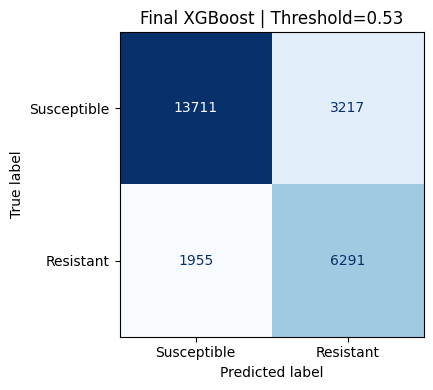

In [14]:
# ============================================================
# CELL 6 — Standalone Model Testing (Holdout Set)
# ============================================================

import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("Loading saved XGBoost model...")
loaded_model = joblib.load('amr_xgb_model_v4.joblib')

test_probs = loaded_model.predict_proba(X_test[FINAL_FEATURES])[:, 1]

try:
    threshold_to_use = FINAL_THRESHOLD
except NameError:
    threshold_to_use = 0.45   # fallback if run in fresh session

test_preds  = (test_probs >= threshold_to_use).astype(int)
test_auc    = roc_auc_score(y_test, test_probs)
test_f1_res = f1_score(y_test, test_preds, pos_label=1)
test_f1_sus = f1_score(y_test, test_preds, pos_label=0)

print("\n=======================================================")
print("  FINAL HOLDOUT EVALUATION (XGBoost)")
print("=======================================================")
print(f"  Threshold            : {threshold_to_use:.4f}")
print(f"  AUC-ROC              : {test_auc:.4f}")
print(f"  F1 Resistant   (1)   : {test_f1_res:.4f}")
print(f"  F1 Susceptible (0)   : {test_f1_sus:.4f}")
print("=======================================================\n")
print(classification_report(y_test, test_preds, target_names=['Susceptible (0)', 'Resistant (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_preds),
    display_labels=['Susceptible', 'Resistant']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Final XGBoost | Threshold={threshold_to_use:.2f}')
plt.tight_layout()
plt.savefig('confusion_matrix_holdout.png', dpi=300, bbox_inches='tight')
print("Saved: confusion_matrix_holdout.png")
plt.show()


In [17]:
# ============================================================
# CELL 7 — Backup to Google Drive
# ============================================================

import shutil, os
import pandas as pd

drive_folder = '/content/drive/Shareddrives/ML_Loopverse_2.0/XGBoost Model'
os.makedirs(drive_folder, exist_ok=True)

files_to_save = [
    'amr_xgb_model_v4.joblib',
    'amr_ordinal_encoder_v4.joblib',
    'LoopVerse_Submission_XGB.csv',
    'results_v4.png',
    'confusion_matrix_holdout.png',
    'eda_overview.png',
]

print(f"Backing up files to: {drive_folder}\n")
for file in files_to_save:
    if os.path.exists(file):
        shutil.copy2(file, os.path.join(drive_folder, file))
        print(f"✅ Copied {file}")
    else:
        print(f"❌ Not found: {file}")

print("\nSaving DataFrames to Drive...")
for filename, var_name in {'cleaned_labeled_data.csv': 'df_clean'}.items():
    if var_name in globals():
        globals()[var_name].to_csv(os.path.join(drive_folder, filename), index=False)
        print(f"✅ Saved {filename} ({len(globals()[var_name]):,} rows)")
    else:
        print(f"❌ Variable {var_name} not found.")

print("\n✅ Backup complete!")


Backing up files to: /content/drive/Shareddrives/ML_Loopverse_2.0/XGBoost Model

✅ Copied amr_xgb_model_v4.joblib
✅ Copied amr_ordinal_encoder_v4.joblib
✅ Copied LoopVerse_Submission_XGB.csv
✅ Copied results_v4.png
✅ Copied confusion_matrix_holdout.png
✅ Copied eda_overview.png

Saving DataFrames to Drive...
✅ Saved cleaned_labeled_data.csv (125,867 rows)

✅ Backup complete!


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
